In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os

## FBI Data

In [166]:
datadir = "/Users/emily/Downloads/hate_crime/hate_crime"
HC_path = os.path.join(datadir, "hate_crime.csv")

HC_df = pd.read_csv(HC_path)

HC_df.head(10)

,incident_id,data_year,ori,pug_agency_name,pub_agency_unit,agency_type_name,state_abbr,state_name,division_name,region_name,...,offender_race,offender_ethnicity,victim_count,offense_name,total_individual_victims,location_name,bias_desc,victim_types,multiple_offense,multiple_bias
0,43,1991,AR0350100,Pine Bluff,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Aggravated Assault,1.0000000000,Residence/Home,Anti-Black or African American,Individual,S,S
1,44,1991,AR0350100,Pine Bluff,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,2,Aggravated Assault;Destruction/Damage/Vandalis...,1.0000000000,Highway/Road/Alley/Street/Sidewalk,Anti-White,Individual,M,S
2,45,1991,AR0600300,North Little Rock,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,2,Aggravated Assault;Murder and Nonnegligent Man...,2.0000000000,Residence/Home,Anti-White,Individual,M,S
3,46,1991,AR0600300,North Little Rock,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Intimidation,1.0000000000,Residence/Home,Anti-White,Individual,S,S
4,47,1991,AR0670000,Sevier,NaN,County,AR,Arkansas,West South Central,South,...,White,Not Specified,1,Intimidation,1.0000000000,School/College,Anti-Black or African American,Individual,S,S
5,3015,1991,AR0040200,Rogers,NaN,City,AR,Arkansas,West South Central,South,...,White,Not Specified,1,Intimidation,1.0000000000,Highway/Road/Alley/Street/Sidewalk,Anti-Black or African American,Individual,S,S
6,3016,1991,AR0290100,Hope,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Simple Assault,1.0000000000,Highway/Road/Alley/Street/Sidewalk,Anti-White,Individual,S,S
7,3017,1991,AR0350100,Pine Bluff,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Aggravated Assault,1.0000000000,Service/Gas Station,Anti-White,Individual,S,S
8,3018,1991,AR0350100,Pine Bluff,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Robbery,1.0000000000,Grocery/Supermarket,Anti-White,Individual,S,S
9,3019,1991,AR0600200,Little Rock,NaN,City,AR,Arkansas,West South Central,South,...,Black or African American,Not Specified,1,Aggravated Assault,1.0000000000,School/College,Anti-White,Individual,S,S


In [110]:
bias_desc_counts_HC = HC_df['bias_desc'].value_counts()
print(bias_desc_counts_HC.sort_index(ascending=True))

bias_desc
Anti-American Indian or Alaska Native                                                                                2917
Anti-American Indian or Alaska Native;Anti-Arab                                                                         1
Anti-American Indian or Alaska Native;Anti-Asian                                                                        4
Anti-American Indian or Alaska Native;Anti-Asian;Anti-Black or African American;Anti-Islamic (Muslim);Anti-White        1
Anti-American Indian or Alaska Native;Anti-Black or African American                                                   11
                                                                                                                    ...  
Anti-Sikh                                                                                                             894
Anti-Transgender                                                                                                     2175
Anti-Transgend

In [111]:
RHC_df = HC_df[~HC_df['bias_desc'].str.contains('Jewish|Black|Arab|White|Protestant|Other Religion|Islamic|Gay |Asian|Catholic|Alaska Native|Female|Hispanic|Sikh|Transgender|Atheism|Bisexual|Heterosexual|Church of Jesus Christ|Gender Non-Conforming|Buddhist|Eastern Orthodox|Anti-Male|Mental Disability|Hindu|Jehovah|Multiple Races|Multiple Religions|Native Hawaiian or Other Pacific Islander|Other Christian|Other Race/Ethnicity/Ancestry|Physical Disability|Lesbian')]


In [112]:
removed_counts = RHC_df['bias_desc'].value_counts()
print(removed_counts.sort_index(ascending=True))

bias_desc
Unknown (offender's motivation not known)    1
Name: count, dtype: int64


In [113]:
words = ['Jewish', 'Black', 'Arab', 'White', 'Protestant', 'Other Religion', 'Islamic', 'Gay', 'Asian', 'Catholic', 'Alaska Native', 'Female', 'Hispanic', 'Sikh', 'Transgender', 'Atheism', 'Bisexual', 'Heterosexual', 'Church of Jesus Christ', 'Gender Non-Conforming', 'Buddhist', 'Eastern Orthodox', 'Anti-Male', 'Mental Disability', 'Lesbian', 'Hindu|Jehovah', 'Multiple Races', 'Multiple Religions', 'Native Hawaiian or Other Pacific Islander', 'Other Christian', 'Other Race', 'Ethnicity', 'Ancestry', 'Physical Disability']
pattern = '|'.join(words)
extracted_words = HC_df['bias_desc'].str.extractall(f'({pattern})')
result_df = pd.DataFrame({
    'word': extracted_words[0],
    'year': HC_df.loc[extracted_words.index.get_level_values(0), 'data_year'].values
})
category_counts_by_year = result_df.groupby(['word', 'year']).size().reset_index(name='count')
print(category_counts_by_year)

              word  year  count
0    Alaska Native  1991     11
1    Alaska Native  1992     26
2    Alaska Native  1993     28
3    Alaska Native  1994     25
4    Alaska Native  1995     41
..             ...   ...    ...
930          White  2020   1112
931          White  2021   1164
932          White  2022   1013
933          White  2023    868
934          White  2024    851

[935 rows x 3 columns]


In [114]:
category_counts_by_year.to_excel('hate_crime_types_per_year1.xlsx', index=False)

## ADL Data

In [133]:
JHCmask = HC_df['bias_desc'].str.contains('Jewish')
JHC_df = HC_df[JHCmask]
JHC_df.head()
JHC_df.shape

(34571, 28)

In [117]:
mask = HC_df['bias_desc'].str.contains('Jewish') & (HC_df['data_year'] == 2024)
JHC24_df = HC_df[mask]
JHC24_df.head()
JHC24_df.shape

(2041, 28)

In [126]:
counts_by_state1 = JHC_df['state_name'].value_counts()
print(counts_by_state1.sort_index(ascending=True))

state_name
Alabama                   18
Alaska                     9
Arizona                  764
Arkansas                  12
California              4842
Colorado                 438
Connecticut              655
Delaware                 106
District of Columbia      91
Federal                  142
Florida                  795
Georgia                   89
Hawaii                    10
Idaho                     67
Illinois                 666
Indiana                  157
Iowa                      55
Kansas                    78
Kentucky                 105
Louisiana                 26
Maine                    125
Maryland                 947
Massachusetts           2017
Michigan                 600
Minnesota                368
Mississippi                5
Missouri                 150
Montana                   51
Nebraska                  82
Nevada                   211
New Hampshire            151
New Jersey              7169
New Mexico                46
New York                9275
Nor

In [127]:
counts_by_state1.to_excel('antisemitic_incidents_by_state_2024.xlsx', index=False)

In [128]:
counts_by_state1 = JHC24_df['state_name'].value_counts()
print(counts_by_state1.sort_index(ascending=True))

state_name
Alabama                   5
Arizona                  21
California              316
Colorado                 36
Connecticut              34
Delaware                 11
District of Columbia      4
Federal                  20
Florida                  30
Georgia                   9
Hawaii                    2
Idaho                     4
Illinois                 70
Indiana                  14
Iowa                      5
Kansas                    2
Kentucky                  7
Louisiana                 1
Maine                     7
Maryland                 57
Massachusetts           142
Michigan                 53
Minnesota                28
Missouri                 13
Montana                   1
Nebraska                  3
Nevada                   15
New Hampshire             9
New Jersey              315
New Mexico                1
New York                457
North Carolina           28
North Dakota              2
Ohio                     22
Oklahoma                  4
Oregon   

In [196]:
datadir = "/Users/emily/Downloads"
ADL_path = os.path.join(datadir, "HEATMapData-2014-2024.csv")

ADL_df = pd.read_csv(ADL_path)
new_header = ADL_df.iloc[0]
ADL_df.columns = new_header
ADL_df = ADL_df[1:].reset_index(drop=True)
ADL_df.head()

,id,date,year,city,state,type,ideology,subideology,group,description,image,location_type,type_of_attack,israel_zionism_related
0,2088,02/2014,2014,Rome,GA,Terrorist Plot/Attack,Right Wing (Anti-Government),NaN,NaN,"Terry Eugene Peace, Brian Edward Cannon and Co...",NaN,NaN,Terrorist Plot/Attack,NaN
1,1186,03/2014,2014,Katy,TX,Terrorist Plot/Attack,Right Wing (Anti-Government),NaN,NaN,"Robert James Talbot, Jr was arrested in March ...",NaN,NaN,Terrorist Plot/Attack,NaN
2,1949,07/2014,2014,Pittsburgh,PA,Terrorist Plot/Attack,Right Wing (White Supremacist),NaN,NaN,White supremacist Eric Charles Smith was arres...,NaN,NaN,Terrorist Plot/Attack,NaN
3,50,10/11/2014,2014,Amarillo,TX,Extremist Murder,Right Wing (White Supremacist),NaN,NaN,Aryan Brotherhood of Texas member William Chet...,NaN,NaN,Extremist Murder,NaN
4,2674,10/23/2014,2014,Wilkinsburg,PA,Extremist Murder,Right Wing (Anti-Government),NaN,NaN,Lincoln Levys brutally beat and murdered his i...,NaN,NaN,Extremist Murder,NaN


In [197]:
ADL_df['date'] = pd.to_datetime(
    ADL_df['date'],
    format='mixed',
    errors='coerce'
)
ADL_df['year'] = ADL_df['date'].dt.year

ADL_df.head()

,id,date,year,city,state,type,ideology,subideology,group,description,image,location_type,type_of_attack,israel_zionism_related
0,2088,2014-02-01,2014,Rome,GA,Terrorist Plot/Attack,Right Wing (Anti-Government),NaN,NaN,"Terry Eugene Peace, Brian Edward Cannon and Co...",NaN,NaN,Terrorist Plot/Attack,NaN
1,1186,2014-03-01,2014,Katy,TX,Terrorist Plot/Attack,Right Wing (Anti-Government),NaN,NaN,"Robert James Talbot, Jr was arrested in March ...",NaN,NaN,Terrorist Plot/Attack,NaN
2,1949,2014-07-01,2014,Pittsburgh,PA,Terrorist Plot/Attack,Right Wing (White Supremacist),NaN,NaN,White supremacist Eric Charles Smith was arres...,NaN,NaN,Terrorist Plot/Attack,NaN
3,50,2014-10-11,2014,Amarillo,TX,Extremist Murder,Right Wing (White Supremacist),NaN,NaN,Aryan Brotherhood of Texas member William Chet...,NaN,NaN,Extremist Murder,NaN
4,2674,2014-10-23,2014,Wilkinsburg,PA,Extremist Murder,Right Wing (Anti-Government),NaN,NaN,Lincoln Levys brutally beat and murdered his i...,NaN,NaN,Extremist Murder,NaN


In [140]:


Lmask = ADL_df['type_of_attack'].str.contains('LGBTQ')
LADL_df = ADL_df[Lmask]
LADL_df.head()
LADL_df.shape

(443, 14)

In [198]:
Jmask = ADL_df['type_of_attack'].str.contains('Antisemitic')
JADL_df = ADL_df[Jmask]
JADL_df.head()
JADL_df.shape

(33905, 14)

In [142]:
type_counts = ADL_df['type_of_attack'].value_counts()
print(type_counts.sort_index(ascending=True))

type_of_attack
Anti-LGBTQ+ Incident: Assault;Antisemitic Incident: Assault                                           1
Anti-LGBTQ+ Incident: Assault;White Supremacist Event                                                 1
Anti-LGBTQ+ Incident: Harassment;Antisemitic Incident: Harassment                                    89
Anti-LGBTQ+ Incident: Harassment;Antisemitic Incident: Harassment;White Supremacist Event            13
Anti-LGBTQ+ Incident: Harassment;Antisemitic Incident: Harassment;White Supremacist Propaganda      136
Anti-LGBTQ+ Incident: Harassment;White Supremacist Event                                             36
Anti-LGBTQ+ Incident: Harassment;White Supremacist Propaganda                                        10
Anti-LGBTQ+ Incident: Vandalism;Antisemitic Incident: Vandalism                                      35
Anti-LGBTQ+ Incident: Vandalism;Antisemitic Incident: Vandalism;White Supremacist Propaganda          1
Anti-LGBTQ+ Incident: Vandalism;White Supremacist

In [143]:
antisemitic_rows = ADL_df[ADL_df['type_of_attack'].str.contains('Antisemitic')]
antisemitic_counts = len(antisemitic_rows)

LGBTQ_rows = ADL_df[ADL_df['type_of_attack'].str.contains('LGBTQ')]
LGBTQ_counts = len(LGBTQ_rows)

antisemitic_LGBTQ_rows = ADL_df[(ADL_df['type_of_attack'].str.contains('Antisemitic')) & (ADL_df['type_of_attack'].str.contains('LGBT'))]
antisemitic_LGBTQ_counts = len(antisemitic_LGBTQ_rows)

print('Number of Antisemitic Incidents: ', antisemitic_counts)
print('Number of Anti-LGBTQ+ Incidents: ', LGBTQ_counts)
print('Number of Antisemitic and Anti-LGBTQ+ Incidents: ', antisemitic_LGBTQ_counts)
print('Percent of Antisemitic Incidents That Are Also Anti-LGBTQ+: ', (antisemitic_LGBTQ_counts / antisemitic_counts)*100, '%')
      

Number of Antisemitic Incidents:  33905
Number of Anti-LGBTQ+ Incidents:  443
Number of Antisemitic and Anti-LGBTQ+ Incidents:  358
Percent of Antisemitic Incidents That Are Also Anti-LGBTQ+:  1.0558914614363664 %


In [144]:
ADL_df['year'].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype=int32)

In [145]:
J_or_L_df = ADL_df[(ADL_df['type_of_attack'].str.contains('Antisemitic')) | (ADL_df['type_of_attack'].str.contains('LGBT'))]
print(J_or_L_df.shape)
J_or_L_df.head()

(33990, 14)


,id,date,year,city,state,type,ideology,subideology,group,description,image,location_type,type_of_attack,israel_zionism_related
101,1801,2016-01-01,2016,Brooklyn,NY,Antisemitic Incident:Vandalism,NaN,NaN,NaN,"The words ""Die Yuppies"" and swastika traced in...",NaN,NaN,Antisemitic Incident:Vandalism,NaN
102,1855,2016-01-01,2016,Orlando,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Non-Jewish elementary school student told Jewi...,NaN,Non-Jewish School,Antisemitic Incident:Harassment,NaN
103,1878,2016-01-01,2016,Palm Beach Gardens,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Jewish school received a bomb threat.,NaN,Jewish Institution / School,Antisemitic Incident:Harassment,NaN
104,1966,2016-01-01,2016,Ponte Vedra Beach,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Jewish student witnessed peer receive a text f...,NaN,Non-Jewish School,Antisemitic Incident:Harassment,NaN
105,2038,2016-01-01,2016,Reading,PA,Antisemitic Incident:Vandalism,NaN,NaN,NaN,"School's grounds vandalized with swastikas, 66...",NaN,Non-Jewish School,Antisemitic Incident:Vandalism,NaN


In [146]:
J_and_L_df = ADL_df[(ADL_df['type_of_attack'].str.contains('Antisemitic')) & (ADL_df['type_of_attack'].str.contains('LGBT'))]
print(J_and_L_df.shape)
J_and_L_df.head()

(358, 14)


,id,date,year,city,state,type,ideology,subideology,group,description,image,location_type,type_of_attack,israel_zionism_related
31305,42014,2022-06-01,2022,Waterloo,IA,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,Right Wing (White Supremacist),NaN,Crew 319,Individuals associated with white supremacist ...,NaN,NaN,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,NaN
31306,42045,2022-06-01,2022,West Essex,NJ,Anti-LGBTQ+ Incident:Vandalism;Antisemitic Inc...,NaN,NaN,NaN,A student vandalized school property with anti...,NaN,NaN,Anti-LGBTQ+ Incident:Vandalism;Antisemitic Inc...,NaN
31307,42068,2022-06-01,2022,Tampa,FL,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,Right Wing (White Supremacist),NaN,Goyim Defense League,Individuals associated with the antisemitic Go...,NaN,NaN,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,NaN
31308,42084,2022-06-01,2022,Mountain Brook,AL,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,Right Wing (White Supremacist),NaN,Goyim Defense League,Individuals associated with the antisemitic Go...,NaN,NaN,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,NaN
31309,42091,2022-06-01,2022,Columbia,TN,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,Right Wing (White Supremacist),NaN,"Goyim Defense League,Ku Klux Klan",Individuals associated with the antisemitic Go...,NaN,NaN,Anti-LGBTQ+ Incident:Harassment;Antisemitic In...,NaN


In [147]:
J_and_L_df['quotes'] = J_and_L_df['description'].str.findall(r'"([^"]*)"')


/var/folders/pj/15jvq4kj0qv4k1h0rfyjw4dm0000gn/T/ipykernel_97846/2182491087.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  J_and_L_df['quotes'] = J_and_L_df['description'].str.findall(r'"([^"]*)"')


In [148]:
J_and_L_df.head()
J_and_L_df.shape

(358, 15)

In [149]:
word_counts = J_and_L_df['quotes'].str.split().explode().value_counts()
print(word_counts)

Series([], Name: count, dtype: int64)


In [150]:
from collections import Counter
from itertools import chain

words_list = []
for item in J_and_L_df['quotes'].tolist():
    # Check if the item is a string before splitting
    if isinstance(item, str):
        words_list.extend(item.split())
    # If it's already a list, extend directly
    elif isinstance(item, list):
        words_list.extend(item)
counter = Counter(words_list)

# Convert the counter to a pandas Series for display/further manipulation (optional)
word_counts_counter = pd.Series(counter).sort_values(ascending=False)

counter = Counter(words_list)

# Convert the counter to a pandas Series for display/further manipulation (optional)
word_counts_counter = pd.Series(counter).sort_values(ascending=False)

print(word_counts_counter)

Every single aspect of Disney child grooming is Jewish.     69
Every single aspect of the LGBTQ+ movement is Jewish.       21
Every single aspect of Disney child grooming is Jewish      12
Every single aspect of the LGBTQ Movement is Jewish.         6
Every single aspect of Disney child grooming is Jewish,      5
                                                            ..
F*ggot                                                       1
Every single aspect of gun control is Jewish,                1
Every single aspect of the media is Jewish,                  1
Every single aspect of mass migration is Jewish              1
faggot Jew                                                   1
Length: 236, dtype: int64


In [151]:
words_series = pd.Series(words_list)
wc = words_series.str.split().explode().value_counts()
wc1 = wc.drop(['of','is','the','a','The','and'])
print(wc1)

Every         226
aspect        224
single        214
Jewish.       139
child          95
             ... 
Disgusting      1
us.             1
Scene           1
Nashville       1
dirty           1
Name: count, Length: 633, dtype: int64


In [152]:
total_phrase_count = words_series.str.count('Every single aspect').sum()

print(f"Total occurrences: {total_phrase_count}")

Total occurrences: 214


In [153]:
bias_desc_counts_JL = J_and_L_df['group'].value_counts()
print(bias_desc_counts_JL.sort_index(ascending=True))
bias_desc_counts_JL.shape

group
14 First,Aryan Freedom Network (AFN),Order of the Black Sun (OBS),Southern Sons Active Club      1
Active Club                                                                                      1
Active Clubs                                                                                     1
Aryan Freedom Network (AFN)                                                                      1
Blood Tribe                                                                                      1
Crew 319                                                                                         1
Goyim Defense League                                                                            63
Goyim Defense League (GDL)                                                                     131
Goyim Defense League (GDL),National Justice Party (NJP)                                          1
Goyim Defense League (GDL),Order of the Black Sun (OBS)                                          1
Goyi

(25,)

In [60]:
GDL_df = JADL_df['group'].str.contains('GDL').value_counts()
print(GDL_df)

group
False    3468
True      864
Name: count, dtype: int64


### The Goyim Defense League is associated with 201 of the incidents that are classified as both Antisemitic and Anti-LGBTQ. These incidents make up 13.6% of the total Antisemitic incidents they have been a part of.

### What is the Goyim Defense League (GDL)? (Global network)
* 'Goyim' is a Hebrew and Yiddish term that refers to non-Jewish people
* The GDL is a white supremacist, antisemitic neo-Nazi group
* "The GDL is predicated on conspiratorial views about a supposedly rotten **US government**, where those in positions of power, as well as those in positions of influence in entertainment media and the healthcare system, are **all anti-white Jewish villains.**"
### (ADL)
* "GDL’s overarching goal is to expel Jews from America."
* "Minadeo and other GDL activists often play to their various audiences, shouting “white power” when among white supremacists, criticizing Israel when speaking to Muslims, or attempting to ingratiate themselves with Black people by repeating the antisemitic canard that Jews were responsible for the transatlantic slave trade."
* "Since the beginning of its “every aspect of XXX is Jewish” campaign in December 2020, GDL has distributed antisemitic propaganda on at least 790 occasions in 46 different states and Washington DC."
* **Fliers on the ADL page**
* "In 2023, Minadeo posed as an offensive caricature of an LGBTQ+ Jewish person at an Orlando City Council meeting. Calling himself “Tammy Cohen” and feigning outrage, Minadeo shared GDL propaganda. After the clip of the incident was shared widely in GDL spaces online, Minadeo continues to use his Tammy Cohen persona to troll people on social media."
* 

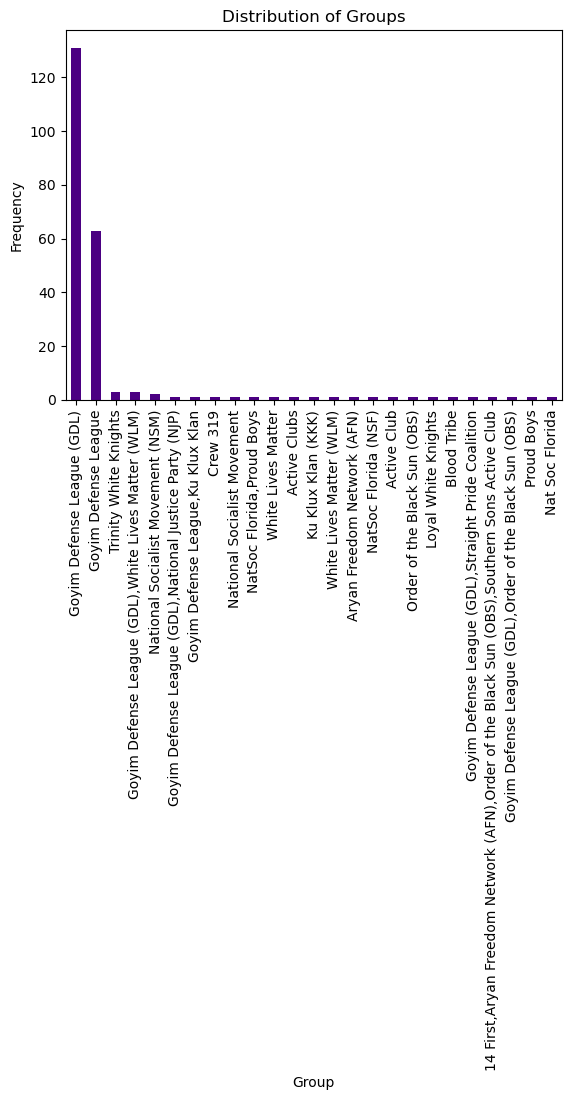

In [30]:
import matplotlib.pyplot as plt
import numpy as np

bias_desc_counts_JL.plot(kind='bar', color='indigo')

# Add labels and title
plt.title('Distribution of Groups')
plt.xlabel('Group')
plt.ylabel('Frequency')

# Display the plot
plt.show()

## FBI Incidents by Population

In [31]:
jewish_pop = 7500000 #7.5M of us population is jewish
black_pop = 48300000 #48.3M of us population is black
hispanic_pop = 68000000 #68M of us population is hispanic
islamic_pop = 4500000 #4.5M of us population is muslim
white_pop = 204000000 #204M of us population is white

In [32]:
FBI_antisemitic_rows = category_counts_by_year[category_counts_by_year['word'].str.contains('Jewish')]
FBI_antisemitic_counts = category_counts_by_year['count'].sum()

FBI_black_rows = category_counts_by_year[(category_counts_by_year['word'].str.contains('Black'))] #& (ADL_df['type_of_attack'].str.contains('LGBT'))]
FBI_black_counts = category_counts_by_year['count'].sum()

FBI_hispanic_rows = category_counts_by_year[category_counts_by_year['word'].str.contains('Hispanic')]
FBI_hispanic_counts = category_counts_by_year['count'].sum()

FBI_black_rows = category_counts_by_year[(category_counts_by_year['word'].str.contains('Black'))]
FBI_black_counts = category_counts_by_year['count'].sum()

FBI_islamic_rows = category_counts_by_year[(category_counts_by_year['word'].str.contains('Islamic'))]
FBI_islamic_counts = category_counts_by_year['count'].sum()

FBI_white_rows = category_counts_by_year[(category_counts_by_year['word'].str.contains('White'))]
FBI_white_counts = category_counts_by_year['count'].sum()

print('Number of Antisemitic Incidents by Population: ', FBI_antisemitic_counts / jewish_pop)
print('Number of Anti-Black Incidents by Population: ', FBI_black_counts / black_pop)
print('Number of Anti-Hispanic Incidents by Population: ', FBI_hispanic_counts / hispanic_pop)
print('Number of Anti-Islamic Incidents by Population: ', FBI_islamic_counts / islamic_pop)
print('Number of Anti-White Incidents by Population: ', FBI_white_counts / white_pop)



Number of Antisemitic Incidents by Population:  0.043834
Number of Anti-Black Incidents by Population:  0.006806521739130435
Number of Anti-Hispanic Incidents by Population:  0.0048346323529411765
Number of Anti-Islamic Incidents by Population:  0.07305666666666667
Number of Anti-White Incidents by Population:  0.0016115441176470589


### Heat Map

In [82]:
datadir = "/Users/emily/Downloads"
HM_path = os.path.join(datadir, "Heat_Map_ds.csv")

HM_df = pd.read_csv(HM_path)
HM_df.head()

,State,Incidents,State Pop (est. 2024),"Incidents per 100,000",Jewish Pop,Jewish Pop Percent,Incidents per 1000 Jews,Median Household Income,"PVI (D: < 0, R: > 0)",Diversity Index
0,Alabama,5,5157699,0.096942,18080,0.350544,0.276549,66659,15,53.1
1,Alaska,0,740133,0.000000,6530,0.882274,0.000000,95665,8,62.8
2,Arizona,21,7582384,0.276958,132360,1.745625,0.158658,81486,2,61.5
3,Arkansas,0,3088354,0.000000,5120,0.165784,0.000000,62106,16,49.8
4,California,316,39431263,0.801395,1259325,3.193722,0.250928,100149,-13,69.7


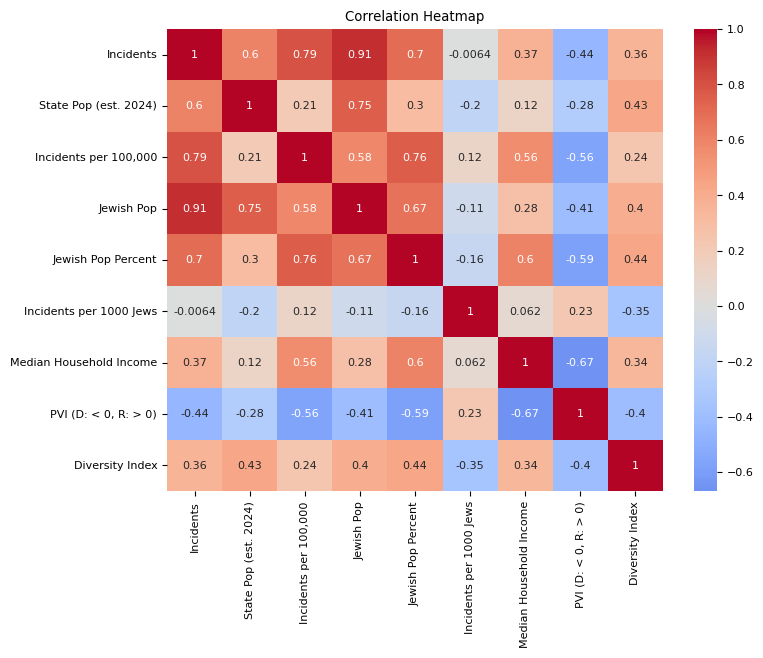

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
HM_nstate_df = HM_df.drop('State', axis=1)
corr_matrix = HM_nstate_df.corr(numeric_only=True)

# 3. Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

# 4. Show the plot
plt.title('Correlation Heatmap')
plt.show()

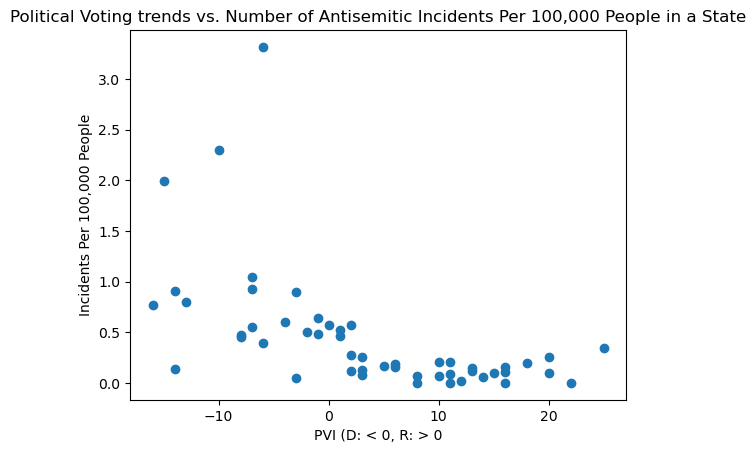

In [35]:
plt.scatter(HM_nstate_df['PVI (D: < 0, R: > 0'], HM_nstate_df['Incidents Per 100,000 People'])

# Add details
plt.title("Political Voting trends vs. Number of Antisemitic Incidents Per 100,000 People in a State")
plt.xlabel("PVI (D: < 0, R: > 0")
plt.ylabel("Incidents Per 100,000 People")

plt.show()

In [47]:
import matplotlib
print(matplotlib.__version__)

3.7.2


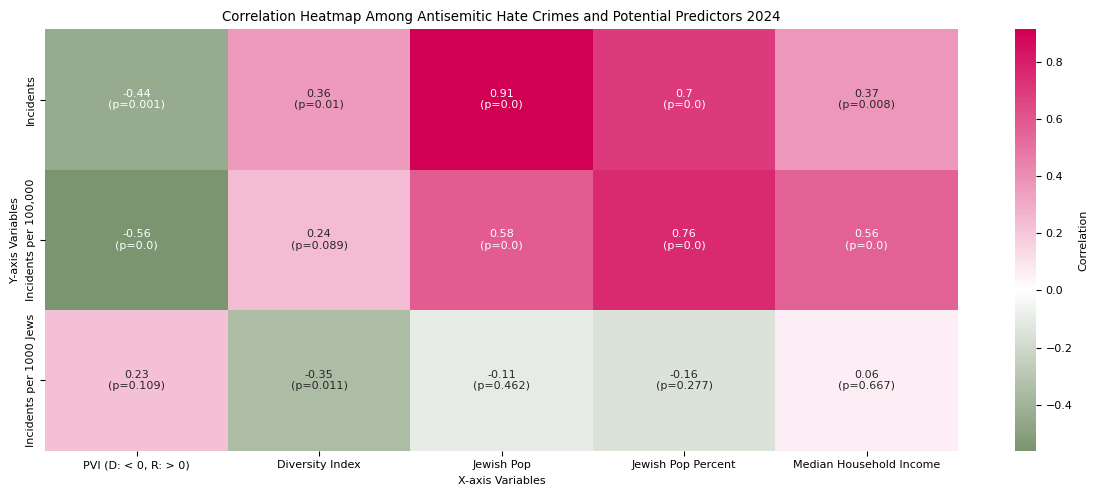

In [85]:
from scipy.stats import pearsonr
import matplotlib
from matplotlib import colormaps
list(colormaps)
from matplotlib.colors import LinearSegmentedColormap

x_vars = ['PVI (D: < 0, R: > 0)', 'Diversity Index', 'Jewish Pop', 'Jewish Pop Percent', 'Median Household Income']  # X-axis variables
y_vars = ['Incidents', 'Incidents per 100,000', 'Incidents per 1000 Jews']  # Y-axis variables


# Function to compute correlation + p-value matrices for custom axes
def corr_p_custom(df, rows, cols):  # Changed parameter name from HM_nstate_df to df for consistency
    corr = pd.DataFrame(index=rows, columns=cols, dtype=float)
    pvals = pd.DataFrame(index=rows, columns=cols, dtype=float)

    for r in rows:
        for c in cols:
            r_val, p_val = pearsonr(df[r], df[c])
            corr.loc[r, c] = r_val
            pvals.loc[r, c] = p_val

    return corr, pvals

corr, pvals = corr_p_custom(HM_nstate_df, y_vars, x_vars)

# Create annotation matrix: "r\n(p)"
annot = corr.round(2).astype(str) + "\n(p=" + pvals.round(3).astype(str) + ")"

my_cmap = LinearSegmentedColormap.from_list("custom", ["#2B5318", "white", "#D20055"])

plt.figure(figsize=(12, 5))
plt.rcParams.update({'font.size': 8})
sns.heatmap(
    corr,
    annot=annot,
    fmt="",
    cmap=my_cmap,
    center=0,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap Among Antisemitic Hate Crimes and Potential Predictors 2024")
plt.xlabel("X-axis Variables")
plt.ylabel("Y-axis Variables")
plt.tight_layout()
plt.show()

In [72]:
print(HM_df[['State', 'Incidents Per 100,000 People']].sort_values('Incidents Per 100,000 People', ascending=False))

                   State  Incidents Per 100,000 People
30            New Jersey                      3.315492
32              New York                      2.300268
21         Massachusetts                      1.989863
7               Delaware                      1.045710
6            Connecticut                      0.925153
20              Maryland                      0.910075
46              Virginia                      0.896587
4             California                      0.801395
45               Vermont                      0.771018
29         New Hampshire                      0.638736
5               Colorado                      0.604281
38          Pennsylvania                      0.573449
8   District of Columbia                      0.569598
13              Illinois                      0.550741
22              Michigan                      0.522659
19                 Maine                      0.498216
23             Minnesota                      0.483329
47        

## Regression Models

### Multiple Linear Regression

In [103]:
datadir = "/Users/emily/Downloads"
antisemitic_path = os.path.join(datadir, "Data 400 Final Project Analysis.xlsx")

all_sheets = pd.read_excel(antisemitic_path, sheet_name=None)
print(all_sheets.keys())

dict_keys(['All Crimes', 'Antisemitic', 'Anti-LGBTQ+', 'Sources'])


In [104]:
All_df = all_sheets['All Crimes']
AS_df = all_sheets['Antisemitic']
LG_df = all_sheets['Anti-LGBTQ+']

In [105]:
AS_df.head()
AS1_df = AS_df.drop(['State', 'Incident Count 2024', 'Incidents per 100,000', 'Incidents per 1000 Jews'], axis=1)

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
# 1) Define features and target (no encoding yet)
X_raw = AS1_df[[
 "Jewish Pop", "ADL Incidents per 1000 Jews", "Population Density", "Median Household Income",
 "% in Poverty 2024", "PVI", "Diversity Index", "Hate Crime Law Bias Coverage"
]]
y = AS1_df['ADL Incidents per 100,000']
# 2) Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
 X_raw, y, test_size=0.2, random_state=42
)
# 3) One-hot encode AFTER the split, then align columns
X_train = pd.get_dummies(X_train_raw, drop_first=True)
X_test = pd.get_dummies(X_test_raw, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
# 4) Fit multiple linear regression
model = LinearRegression()
model.fit(X_train, y_train)
# 5) Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
# 6) Evaluate fit
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("R^2 (train):", r2_train)
print("R^2 (test): ", r2_test)
print("RMSE (train):", rmse_train)
print("RMSE (test): ", rmse_test)
# 7) Coefficients (sorted by absolute magnitude for readability)
pd.set_option('display.float_format', '{:.10f}'.format)
coef_series = pd.Series(model.coef_, index=X_train.columns).sort_values(key=np.abs, ascending=False)
print("\nIntercept:", model.intercept_)
print("\nCoefficients:\n", coef_series)

R^2 (train): 0.9131865731891478
R^2 (test):  0.35192341826226736
RMSE (train): 0.9997746878307476
RMSE (test):  1.9565154524131911

Intercept: -0.8201436239274074

Coefficients:
 Hate Crime Law Bias Coverage   -0.3917744029
% in Poverty 2024               0.2075454061
PVI                            -0.1148805050
ADL Incidents per 1000 Jews     0.0635406940
Diversity Index                -0.0495920199
Population Density              0.0015417199
Median Household Income         0.0000655470
Jewish Pop                     -0.0000004305
dtype: float64


### Lasso

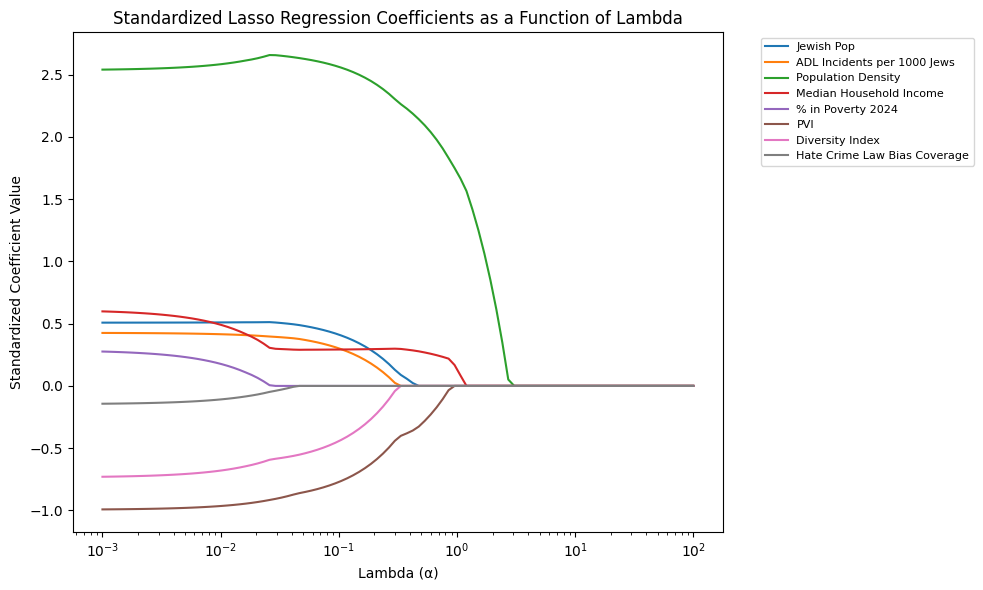

In [94]:
## Lasso Regression: Coefficient Paths
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
# 1) Define features and target
X_raw = AS1_df[[
 "Jewish Pop", "ADL Incidents per 1000 Jews", "Population Density", "Median Household Income",
 "% in Poverty 2024", "PVI", "Diversity Index", "Hate Crime Law Bias Coverage"
]]
y = AS1_df['ADL Incidents per 100,000']
# 2) One-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)
# 3) Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 4) Fit Lasso models for a range of lambda (alpha) values
# Lasso typically benefits from a slightly smaller alpha range than Ridge.
alphas = np.logspace(-3, 2, 100) # λ from 0.001 to 100
coefs = []
for alpha in alphas:
 lasso = Lasso(alpha=alpha, max_iter=10000)
 lasso.fit(X_scaled, y)
 coefs.append(lasso.coef_)
coefs = np.array(coefs)
# 5) Plot coefficient paths
plt.figure(figsize=(10, 6))
plt.plot(alphas, coefs)
plt.xscale("log")
plt.xlabel("Lambda (α)")
plt.ylabel("Standardized Coefficient Value")
plt.title("Standardized Lasso Regression Coefficients as a Function of Lambda")
plt.legend(X.columns, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Best lambda (alpha) for Lasso: 0.0032


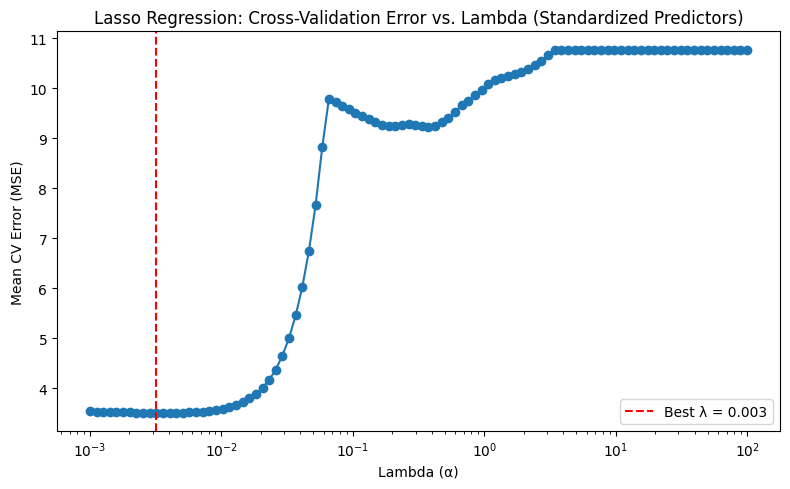

In [95]:
## Lasso Regression with Cross-Validation (using GridSearchCV)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
# 1) Define the range of lambda (alpha) values to test
# Lasso is more sensitive to alpha, so we use a smaller range.
alphas = np.logspace(-3, 2, 100) # 0.001 → 100

# 2) Create a 5-fold cross-validation setup
# Each fold uses 80% of the data for training and 20% for validation.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 3) Set up GridSearchCV to test each alpha value
# - estimator: Lasso regression (with a higher max_iter to ensure convergence)
# - scoring: negative mean squared error (smaller = better)
# - cv: the 5-fold splitter defined above
# - return_train_score: True lets us inspect both train and test errors
gs_lasso = GridSearchCV(
 estimator=Lasso(max_iter=10000),
 param_grid={"alpha": alphas},
 scoring="neg_mean_squared_error",
 cv=cv,
 return_train_score=True,
)

# 4) Fit the grid search on the standardized predictors
# Each model is trained and validated internally across the 5 folds.
gs_lasso.fit(X_scaled, y)

# 5) Identify the best alpha (lambda) value that minimizes CV error
best_alpha_lasso = gs_lasso.best_params_["alpha"]
print(f"Best lambda (alpha) for Lasso: {best_alpha_lasso:.4f}")

# 6) Extract the mean cross-validation MSE for plotting
mean_cv_mse_lasso = -gs_lasso.cv_results_["mean_test_score"] # convert from negative MSE

# 7) Plot cross-validation error vs. lambda
plt.figure(figsize=(8,5))
plt.semilogx(alphas, mean_cv_mse_lasso, marker="o")
plt.axvline(best_alpha_lasso, linestyle="--", color="red", label=f"Best λ = {best_alpha_lasso:.3f}")
plt.xlabel("Lambda (α)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso Regression: Cross-Validation Error vs. Lambda (Standardized Predictors)")
plt.legend()
plt.tight_layout()
plt.show()

In [96]:
# 1) Fit OLS (no regularization)
ols = LinearRegression()
ols.fit(X_scaled, y)
ols_coefs = pd.Series(ols.coef_, index=X.columns)

# 3) Fit Lasso with best λ from CV
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_scaled, y)
lasso_coefs = pd.Series(lasso_best.coef_, index=X.columns)

coef_compare = pd.DataFrame({
 "OLS": ols_coefs,
 f"Lasso (λ={best_alpha_lasso:.3f})": lasso_coefs
})
# 5) Sort by absolute OLS coefficient for readability
coef_compare = coef_compare.reindex(ols_coefs.abs().sort_values(ascending=False).index)
# 6) Display
print(coef_compare)

                                   OLS  Lasso (λ=0.003)
Population Density            2.536402         2.552121
PVI                          -0.995257        -0.985596
Diversity Index              -0.735531        -0.717744
Median Household Income       0.611104         0.572318
Jewish Pop                    0.508099         0.508821
ADL Incidents per 1000 Jews   0.426843         0.423144
% in Poverty 2024             0.287463         0.251811
Hate Crime Law Bias Coverage -0.147029        -0.134666


In [97]:
## Compare Model Fit: OLS vs Ridge vs Lasso
# --- Assumes these objects exist: X_scaled, y, best_alpha, best_alpha_lasso ---
# 1) Fit models
ols = LinearRegression().fit(X_scaled, y)
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_scaled, y)
# 2) Make predictions
y_pred_ols = ols.predict(X_scaled)
y_pred_lasso = lasso.predict(X_scaled)
# 3) Compute R² and RMSE for each model
results = {
 "Model": ["OLS", f"Lasso (λ={best_alpha_lasso:.3f})"],
 "R²": [
 r2_score(y, y_pred_ols),
 r2_score(y, y_pred_lasso)
 ],
 "RMSE": [
 np.sqrt(mean_squared_error(y, y_pred_ols)),
 np.sqrt(mean_squared_error(y, y_pred_lasso))
 ]
}
# 4) Create DataFrame and display
fit_compare = pd.DataFrame(results)
print(fit_compare.to_string(index=False, float_format="%.4f"))

          Model     R²   RMSE
            OLS 0.8927 1.0536
Lasso (λ=0.003) 0.8927 1.0537


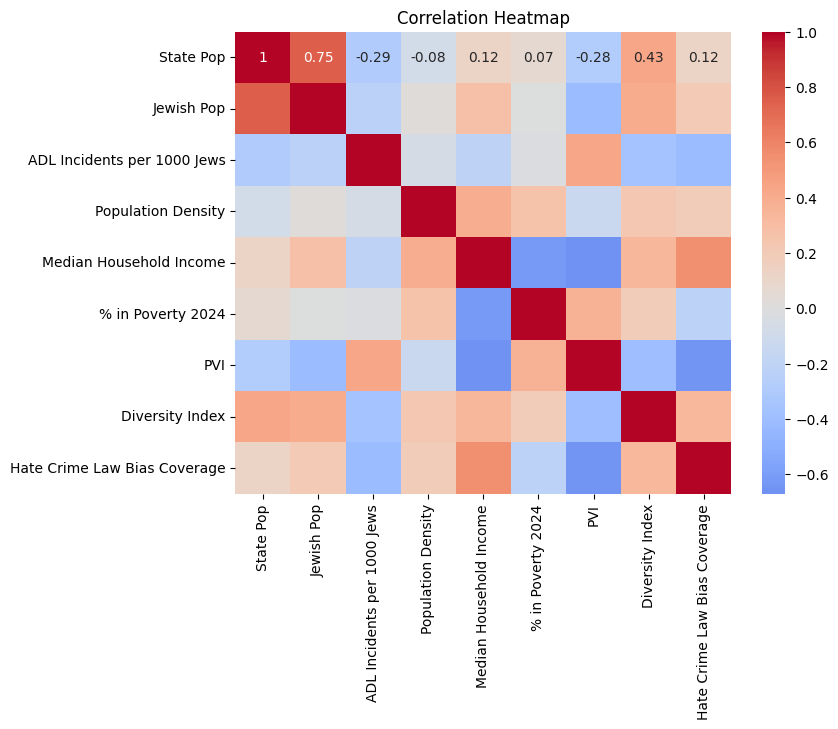

In [92]:
quant_vars = ["State Pop", "Jewish Pop", "ADL Incidents per 1000 Jews", "Population Density", "Median Household Income",
 "% in Poverty 2024", "PVI", "Diversity Index", "Hate Crime Law Bias Coverage"]
corr_matrix = AS_df[quant_vars].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)

# 4. Show the plot
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
wwwsmffff

In [159]:
plt.plot(kind='bar')
plt.title
JHC_df JADL_df

SyntaxError: invalid syntax (1921148147.py, line 3)

In [177]:
mask1 = HC_df['bias_desc'].str.contains('Jewish') & (HC_df['data_year'] >= 2014)
JHC14_df = HC_df[mask1]
JHC14_df.shape
JHC14_df.head()

,incident_id,data_year,ori,pug_agency_name,pub_agency_unit,agency_type_name,state_abbr,state_name,division_name,region_name,...,offender_race,offender_ethnicity,victim_count,offense_name,total_individual_victims,location_name,bias_desc,victim_types,multiple_offense,multiple_bias
169105,169142,2014,AL0011200,Hoover,NaN,City,AL,Alabama,East South Central,South,...,Unknown,Not Specified,1,Simple Assault,1.0000000000,Hotel/Motel/Etc.,Anti-Jewish,Individual,S,S
169131,169158,2014,AZ0039700,Northern Arizona University,NaN,University or College,AZ,Arizona,Mountain,West,...,Unknown,Not Specified,1,Destruction/Damage/Vandalism of Property,0.0000000000,School/College,Anti-Jewish,Government,S,S
169166,169193,2014,AZ0072300,Phoenix,NaN,City,AZ,Arizona,Mountain,West,...,Unknown,Not Specified,1,Intimidation,1.0000000000,Residence/Home,Anti-Jewish,Individual,S,S
169170,169197,2014,AZ0072300,Phoenix,NaN,City,AZ,Arizona,Mountain,West,...,Unknown,Not Specified,1,Destruction/Damage/Vandalism of Property,0.0000000000,School/College,Anti-Jewish,Business,S,S
169194,169221,2014,AZ0072300,Phoenix,NaN,City,AZ,Arizona,Mountain,West,...,White,Not Specified,1,Simple Assault,1.0000000000,Residence/Home,Anti-Jewish,Individual,S,S


In [192]:
counts_by_year_FBI = JHC14_df['data_year'].value_counts()
print(counts_by_year_FBI.sort_index(ascending=True))

data_year
2014     616
2015     667
2016     707
2017     985
2018     881
2019    1172
2020     979
2021     917
2022    1269
2023    1998
2024    2041
Name: count, dtype: int64


In [193]:
# Convert numerical features stored as object → int64
ADL_df['year'] = ADL_df['year'].astype("int64")
ADL_df.dtypes

0
id                        object
date                      object
year                       int64
city                      object
state                     object
type                      object
ideology                  object
subideology               object
group                     object
description               object
image                     object
location_type             object
type_of_attack            object
israel_zionism_related    object
dtype: object

In [194]:
mask2 = ADL_df['type_of_attack'].str.contains('Antisemitic') & (ADL_df['year'] < 2025)
ADL14_df = ADL_df[mask2]
ADL14_df.shape
ADL14_df.head()

,id,date,year,city,state,type,ideology,subideology,group,description,image,location_type,type_of_attack,israel_zionism_related
101,1801,01/2016,2016,Brooklyn,NY,Antisemitic Incident:Vandalism,NaN,NaN,NaN,"The words ""Die Yuppies"" and swastika traced in...",NaN,NaN,Antisemitic Incident:Vandalism,NaN
102,1855,01/2016,2016,Orlando,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Non-Jewish elementary school student told Jewi...,NaN,Non-Jewish School,Antisemitic Incident:Harassment,NaN
103,1878,01/2016,2016,Palm Beach Gardens,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Jewish school received a bomb threat.,NaN,Jewish Institution / School,Antisemitic Incident:Harassment,NaN
104,1966,01/2016,2016,Ponte Vedra Beach,FL,Antisemitic Incident:Harassment,NaN,NaN,NaN,Jewish student witnessed peer receive a text f...,NaN,Non-Jewish School,Antisemitic Incident:Harassment,NaN
105,2038,01/2016,2016,Reading,PA,Antisemitic Incident:Vandalism,NaN,NaN,NaN,"School's grounds vandalized with swastikas, 66...",NaN,Non-Jewish School,Antisemitic Incident:Vandalism,NaN


In [199]:
counts_by_year_ADL = JADL_df['year'].value_counts()
print(counts_by_year_ADL.sort_index(ascending=True))


year
2016    1267
2017    1986
2018    1879
2019    2107
2020    2025
2021    2717
2022    3698
2023    8871
2024    9355
Name: count, dtype: int64


In [207]:
datadir = "/Users/emily/Downloads"
FBI_ADL_path = os.path.join(datadir, "FBI and ADL.xlsx")

FBI_ADL_df = pd.read_excel(FBI_ADL_path)
FBI_ADL_df.head()

,year,FBI Reported Incidents,ADL Reported Incidents
0,2014,616,912
1,2015,667,941
2,2016,707,1267
3,2017,985,1986
4,2018,881,1879


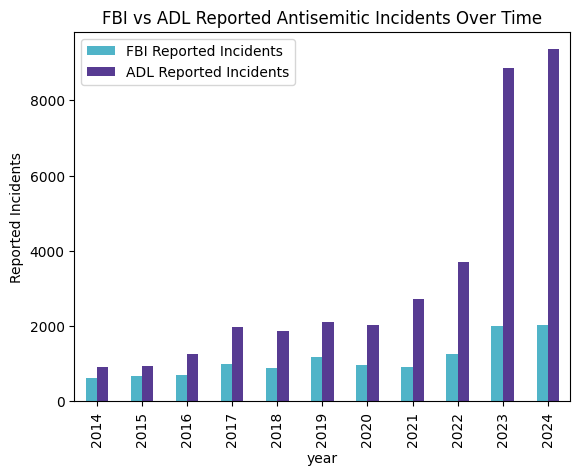

In [213]:
FBI_ADL_df.plot(x='year', y=['FBI Reported Incidents', 'ADL Reported Incidents'], kind='bar', color=['#50b4c8', '#573b92'])
plt.title('FBI vs ADL Reported Antisemitic Incidents Over Time')
plt.ylabel('Reported Incidents')
plt.show()